## Loading all the libraries and requried packages

# Sania Verma (250059406) - Deep Reinforcement learning
This notebook implements PPO Policy algorithm on the Lunar Lander-v3 environment from the Gymnasium library.This notebook implements different experiments.
Experiment 1 implements basic PPO with only 1 epoch per episode
Experiment 2 is the improvement on top of the basic PPO where ppo_steps are 4 and other significant improvements are added
Experiemtn 3 involves changing of the architecture as well as incorporating changes from the experiment 2.

Experiment No 1: Basic PPO implementation
The following are the configurations
1. NUmber of epochs per episode = 1
2. Number of hidden dimensions in the neural networks are 64
3. No dropOut

In [50]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical, Normal
import numpy as np

In [42]:
train_env = gym.make('LunarLander-v3')


In [45]:
class PPOAgent(nn.Module):
    def __init__(self, state_dim, action_dim, is_continuous=False):
        super().__init__()
        self.is_continuous = is_continuous

        # Shared feature extractor
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

        self.actor = nn.Sequential(
            nn.Linear(state_dim, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, action_dim)
        )

        if is_continuous:
            self.log_std = nn.Parameter(torch.zeros(action_dim))

    def get_action_and_value(self, x, action=None):
        value = self.critic(x)
        if not self.is_continuous:
            logits = self.actor(x)
            probs = Categorical(logits=logits)
            if action is None:
                action = probs.sample()
            return action, probs.log_prob(action), probs.entropy(), value
        else:
            mu = self.actor(x)
            std = torch.exp(self.log_std)
            probs = Normal(mu, std)
            if action is None:
                action = probs.sample()
            return action, probs.log_prob(action).sum(1), probs.entropy().sum(1), value

In [46]:
# Device selection (CUDA, MPS, or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

print(f"Using device: {device}")

Using device: cuda


In [52]:
def train_ppo(env_name, is_continuous, episodes=1000):

    env = gym.make(env_name)

    agent = PPOAgent(
        env.observation_space.shape[0],
        env.action_space.shape[0] if is_continuous else env.action_space.n,
        is_continuous
    ).to(device)

    optimizer = optim.Adam(agent.parameters(), lr=3e-4)
    eps_clip = 0.2

    # ADDing the reward_history list to store the rewards in the list
    rewards_history = []

    for ep in range(episodes):

        state, _ = env.reset()
        states, actions, logprobs, rewards, values = [], [], [], [], []

        # collect episode
        while True:
            st = torch.from_numpy(state).float().to(device).unsqueeze(0)

            action, logprob, _, value = agent.get_action_and_value(st)

            next_state, reward, term, trunc, _ = env.step(
                action.cpu().numpy()[0] if is_continuous else action.item()
            )

            states.append(st)
            actions.append(action)
            logprobs.append(logprob)
            rewards.append(reward)
            values.append(value)

            state = next_state
            if term or trunc:
                break

        ep_reward = sum(rewards)

        # STORE REWARD PER EPISODE
        rewards_history.append(ep_reward)

        # compute returns
        returns, g = [], 0
        for r in reversed(rewards):
            g = r + 0.99 * g
            returns.insert(0, g)

        returns = torch.tensor(np.array(returns, dtype=np.float32)).to(device).unsqueeze(1)
        values = torch.cat(values)

        advantages = (returns - values).detach()

        curr_states = torch.cat(states)
        curr_actions = torch.cat(actions)
        curr_logprobs = torch.cat(logprobs).detach()

        _, new_logprobs, entropy, new_values = agent.get_action_and_value(
            curr_states, curr_actions
        )

        ratio = torch.exp(new_logprobs - curr_logprobs)

        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1 - eps_clip, 1 + eps_clip) * advantages

        loss = (
            -torch.min(surr1, surr2).mean()
            + 0.5 * nn.MSELoss()(new_values, returns)
            - 0.01 * entropy.mean()
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if ep % 20 == 0:
            print(f"Ep {ep} | Reward: {ep_reward}")

    print("Training completed.")
    # returning both agent as well as rewards_history
    return agent, rewards_history

In [53]:

agent_lunar, rewards = train_ppo("LunarLander-v3", False)


Ep 0 | Reward: -222.243187574534
Ep 20 | Reward: -151.42797150134908
Ep 40 | Reward: -453.6278078407811
Ep 60 | Reward: -219.81026383391412
Ep 80 | Reward: -150.7981653861644
Ep 100 | Reward: -119.79447966263362
Ep 120 | Reward: -131.27667764973975
Ep 140 | Reward: -117.13686562703856
Ep 160 | Reward: -0.47074479576717465
Ep 180 | Reward: -130.76643445266848
Ep 200 | Reward: -170.52887725503257
Ep 220 | Reward: -97.51210592813437
Ep 240 | Reward: -111.20525728929574
Ep 260 | Reward: -134.1815973107026
Ep 280 | Reward: -310.44767950956077
Ep 300 | Reward: -463.603448816393
Ep 320 | Reward: -179.50093788073224
Ep 340 | Reward: -149.27667418848915
Ep 360 | Reward: -116.84045827981997
Ep 380 | Reward: -120.68701078244574
Ep 400 | Reward: -144.2879129858461
Ep 420 | Reward: -156.39347980813932
Ep 440 | Reward: -248.2946605440609
Ep 460 | Reward: -96.3839474855522
Ep 480 | Reward: -146.13485743117576
Ep 500 | Reward: -104.5785445353946
Ep 520 | Reward: -168.1747041075874
Ep 540 | Reward: -11

In [54]:
import pandas as pd

df = pd.DataFrame({
    "episode": list(range(len(rewards))),
    "reward": rewards
})

df.to_csv("ppo_experiment_1.csv", index=False)

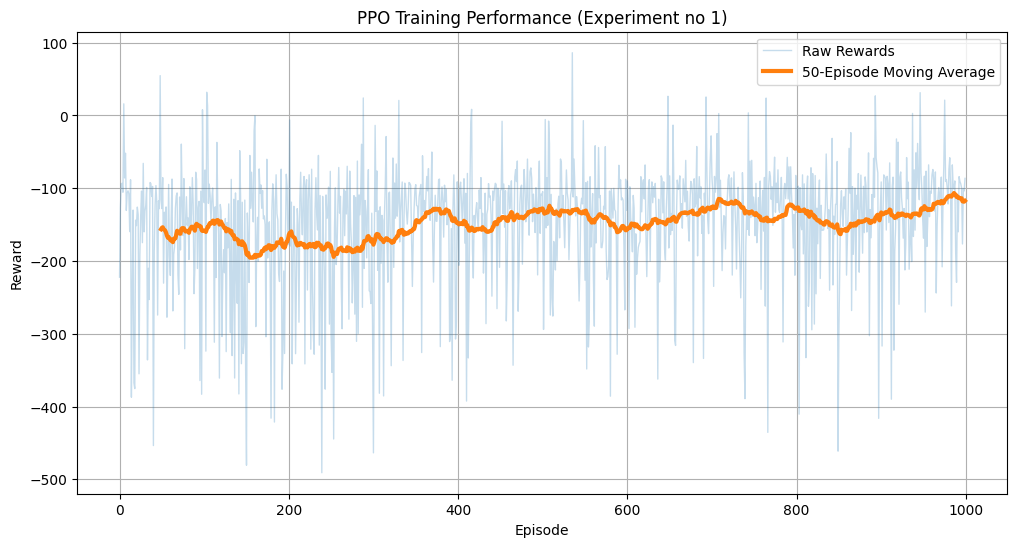

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# load saved CSV
df = pd.read_csv("ppo_experiment_1.csv")
# extract values
episodes = df["episode"]
rewards = df["reward"]
# moving average
window_size = 50
moving_avg = rewards.rolling(window=window_size).mean()
# plot
plt.figure(figsize=(12, 6))
# raw rewards in background
plt.plot(
    episodes,
    rewards,
    alpha=0.25,
    linewidth=1,
    label="Raw Rewards"
)
# moving average on top
plt.plot(
    episodes,
    moving_avg,
    linewidth=3,
    label=f"{window_size}-Episode Moving Average"
)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("PPO Training Performance (Experiment no 1)" )
plt.grid(True)
plt.legend()

plt.show()

Experiment No 2:
The following changes are beign done in this experiment
1. Gradient clipping
2. Normalizing the advantages and returns
3. Passing the backward loss together in one go
4. Keeping the numebr of hidden dimensions = 64 and dropout = 0
5. Changing learning rate


In [24]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Dropout(dropout),
            nn.PReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Dropout(dropout),
            nn.PReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


class ActorCritic(nn.Module):
    def __init__(self, actor, critic):
        super().__init__()

        self.actor = actor
        self.critic = critic

    def forward(self, state):
        return self.actor(state), self.critic(state)

In [25]:
train_env = gym.make('LunarLander-v3')

In [26]:
INPUT_DIM = train_env.observation_space.shape[0]
HIDDEN_DIM = 64   # Number of neurons in the hidden layer
OUTPUT_DIM = train_env.action_space.n

actor = MLP(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM)
critic = MLP(INPUT_DIM, HIDDEN_DIM, 1)

policy = ActorCritic(actor, critic)

In [27]:
MAX_EPISODES = 1000   # Maximum number of episodes are considered to be 1000
optimizer = optim.Adam(policy.parameters(), lr=0.0005)   # settign the learning rate as 0.0005
scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=1.0,
    end_factor=0.1,
    total_iters=MAX_EPISODES
)


In [28]:
def train(env, policy, optimizer, discount_factor, ppo_steps, ppo_clip):

    policy.train()

    states = []
    actions = []
    log_prob_actions = []
    values = []
    rewards = []

    done = False
    episode_reward = 0

    state, _ = env.reset()

    while not done:

        state = torch.FloatTensor(state).unsqueeze(0)

        states.append(state)

        action_pred, value_pred = policy(state)

        action_prob = F.softmax(action_pred, dim=-1)

        dist = distributions.Categorical(action_prob)

        action = dist.sample()

        log_prob_action = dist.log_prob(action)

        state, reward, terminated, truncated, _ = env.step(action.item())  # <-- v3 API
        done = terminated or truncated

        actions.append(action)
        log_prob_actions.append(log_prob_action)
        values.append(value_pred)
        rewards.append(reward)

        episode_reward += reward

    states = torch.cat(states)
    actions = torch.cat(actions)
    log_prob_actions = torch.cat(log_prob_actions)
    values = torch.cat(values).squeeze(-1)

    returns = calculate_returns(rewards, discount_factor)
    advantages = calculate_advantages(returns, values)

    policy_loss, value_loss = update_policy(
        policy,
        states,
        actions,
        log_prob_actions,
        advantages,
        returns,
        optimizer,
        ppo_steps,
        ppo_clip
    )

    return policy_loss, value_loss, episode_reward

In [29]:
def calculate_returns(rewards, discount_factor, normalize=True):

    returns = []
    R = 0

    for r in reversed(rewards):
        R = r + R * discount_factor
        returns.insert(0, R)

    returns = torch.tensor(returns)

    if normalize:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    return returns

In [30]:
def calculate_advantages(returns, values, normalize=True):

    advantages = returns - values

    if normalize:
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    return advantages

In [32]:
def update_policy(policy, states, actions, log_prob_actions,
                  advantages, returns, optimizer, ppo_steps, ppo_clip):
    # variables to store average losses across PPO epochs
    total_policy_loss = 0
    total_value_loss = 0

    states = states.detach()
    actions = actions.detach()
    log_prob_actions = log_prob_actions.detach()
    advantages = advantages.detach()
    returns = returns.detach()

    for _ in range(ppo_steps):
        # forward pass through actor and critic networks
        action_pred, value_pred = policy(states)
        value_pred = value_pred.squeeze(-1)
        # convert actor logits into probability distribution
        action_prob = F.softmax(action_pred, dim=-1)
        dist = distributions.Categorical(action_prob)

        new_log_prob_actions = dist.log_prob(actions)
        # PPO probability ratio:
        # ratio = pi_theta(a|s) / pi_theta_old(a|s)
        policy_ratio = (new_log_prob_actions - log_prob_actions).exp()
        # unclipped PPO objective
        policy_loss_1 = policy_ratio * advantages
        # clipped PPO objective
        # prevents very large policy updates
        policy_loss_2 = torch.clamp(
            policy_ratio,
            min=1.0 - ppo_clip,
            max=1.0 + ppo_clip
        ) * advantages
        # final PPO actor loss
        # take minimum to enforce conservative updates
        policy_loss = -torch.min(policy_loss_1, policy_loss_2).mean()
        # critic loss:
        # Smooth L1 (Huber) loss is more stable than MSE in RL
        value_loss = F.smooth_l1_loss(returns, value_pred).mean()
        # combined policy loss and value loss
        optimizer.zero_grad()
        (policy_loss + value_loss).backward()
        # gradient clipping improves stability
        # prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=0.5)
        optimizer.step()

        total_policy_loss += policy_loss.item()
        total_value_loss  += value_loss.item()
     # return average losses across PPO epochs
    return total_policy_loss / ppo_steps, total_value_loss / ppo_steps

In [33]:
DISCOUNT_FACTOR = 0.99
PPO_STEPS       = 5
PPO_CLIP        = 0.2
train_rewards   = []

for episode in range(1, MAX_EPISODES + 1):
    policy_loss, value_loss, train_reward = train(
        train_env, policy, optimizer,
        DISCOUNT_FACTOR, PPO_STEPS, PPO_CLIP
    )
    train_rewards.append(train_reward)
    scheduler.step()

    if episode % 10 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f'| Episode: {episode:3} | Train Reward: {np.mean(train_rewards[-20:]):7.1f} | LR: {current_lr:.6f} |')

| Episode:  10 | Train Reward:  -196.3 | LR: 0.000495 |
| Episode:  20 | Train Reward:  -218.9 | LR: 0.000491 |
| Episode:  30 | Train Reward:  -200.3 | LR: 0.000486 |
| Episode:  40 | Train Reward:  -183.6 | LR: 0.000482 |
| Episode:  50 | Train Reward:  -195.9 | LR: 0.000477 |
| Episode:  60 | Train Reward:  -197.6 | LR: 0.000473 |
| Episode:  70 | Train Reward:  -194.3 | LR: 0.000468 |
| Episode:  80 | Train Reward:  -190.3 | LR: 0.000464 |
| Episode:  90 | Train Reward:  -218.8 | LR: 0.000459 |
| Episode: 100 | Train Reward:  -211.2 | LR: 0.000455 |
| Episode: 110 | Train Reward:  -170.2 | LR: 0.000450 |
| Episode: 120 | Train Reward:  -156.3 | LR: 0.000446 |
| Episode: 130 | Train Reward:  -203.4 | LR: 0.000441 |
| Episode: 140 | Train Reward:  -242.2 | LR: 0.000437 |
| Episode: 150 | Train Reward:  -384.6 | LR: 0.000432 |
| Episode: 160 | Train Reward:  -438.4 | LR: 0.000428 |
| Episode: 170 | Train Reward:  -301.4 | LR: 0.000423 |
| Episode: 180 | Train Reward:  -212.9 | LR: 0.0

In [34]:
import pandas as pd

df = pd.DataFrame({
    "episode": list(range(1, len(train_rewards)+1)),
    "reward": train_rewards
})

df.to_csv("ppo_rewards_exp2.csv", index=False)

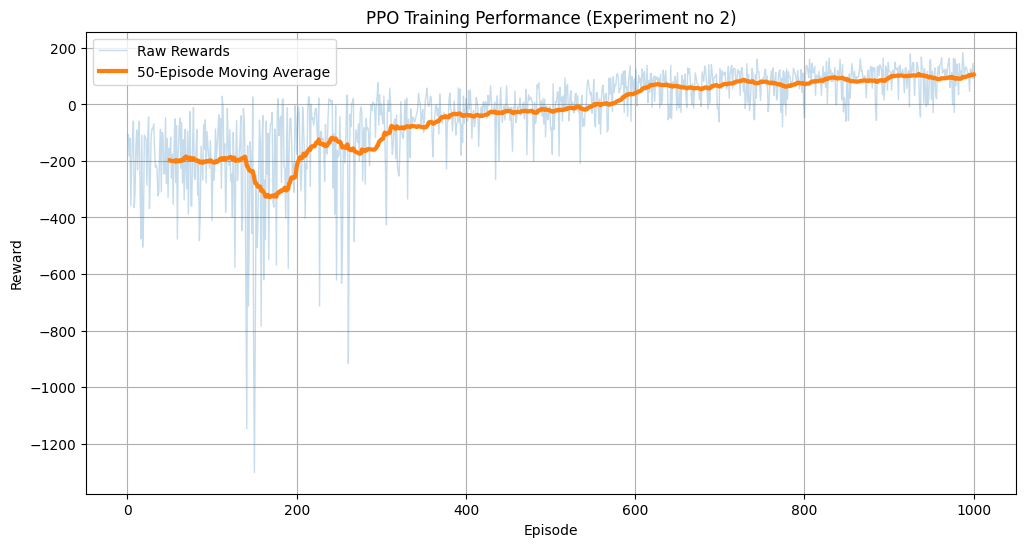

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# load saved CSV
df = pd.read_csv("ppo_rewards_exp2.csv")
# extract values
episodes = df["episode"]
rewards = df["reward"]
# moving average
window_size = 50
moving_avg = rewards.rolling(window=window_size).mean()
# plot
plt.figure(figsize=(12, 6))
# raw rewards in background
plt.plot(
    episodes,
    rewards,
    alpha=0.25,
    linewidth=1,
    label="Raw Rewards"
)
# moving average on top
plt.plot(
    episodes,
    moving_avg,
    linewidth=3,
    label=f"{window_size}-Episode Moving Average"
)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("PPO Training Performance (Experiment no 2)" )
plt.grid(True)
plt.legend()

plt.show()

Experiment No 3:
The following changes are beign done in this experiment
1. Gradient clipping
2. Inializing the weights through the Xavier Normal
3. Normalizing the advantages and returns
4. Passing the backward loss together in one go
5. Keeping the numebr of hidden dimensions = 128
and dropout = 0.1
6. Changing the learning rate


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.distributions as distributions

import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym

Installing required packages for the box2d

In [5]:
!pip install swig
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 121.0 MB/s eta 0:00:00


Considering Luna lander v3 environment from Gymnasium library

In [8]:
train_env = gym.make('LunarLander-v3')

Creating separate classes for the  ActorCritic and Critic where the parameters defined are same
Input layer : 128 features(neurons)

In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Dropout(dropout),
            nn.PReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Dropout(dropout),
            nn.PReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


class ActorCritic(nn.Module):
    def __init__(self, actor, critic):
        super().__init__()

        self.actor = actor
        self.critic = critic

    def forward(self, state):
        return self.actor(state), self.critic(state)

Initializing the number of neurons

In [9]:
INPUT_DIM = train_env.observation_space.shape[0]
HIDDEN_DIM = 128   # Number of neurons in the hidden layer
OUTPUT_DIM = train_env.action_space.n

actor = MLP(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM)
critic = MLP(INPUT_DIM, HIDDEN_DIM, 1)

policy = ActorCritic(actor, critic)

Initializing the weights through Xavier Normal

In [10]:
def init_weights(m):
    if type(m) == nn.Linear:
        torch.nn.init.xavier_normal_(m.weight)
        m.bias.data.fill_(0)

policy.apply(init_weights)

ActorCritic(
  (actor): MLP(
    (net): Sequential(
      (0): Linear(in_features=8, out_features=128, bias=True)
      (1): Dropout(p=0.1, inplace=False)
      (2): PReLU(num_parameters=1)
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): Dropout(p=0.1, inplace=False)
      (5): PReLU(num_parameters=1)
      (6): Linear(in_features=128, out_features=4, bias=True)
    )
  )
  (critic): MLP(
    (net): Sequential(
      (0): Linear(in_features=8, out_features=128, bias=True)
      (1): Dropout(p=0.1, inplace=False)
      (2): PReLU(num_parameters=1)
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): Dropout(p=0.1, inplace=False)
      (5): PReLU(num_parameters=1)
      (6): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)

Definign the number of episodes and optimizer

In [11]:
MAX_EPISODES = 1000   # Maximum number of episodes are considered to be 1000
optimizer = optim.Adam(policy.parameters(), lr=0.0005)   # settign the learning rate as 0.0005
scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=1.0,
    end_factor=0.1,
    total_iters=MAX_EPISODES
)


Training loop

In [12]:
def train(env, policy, optimizer, discount_factor, ppo_steps, ppo_clip):

    policy.train()

    states = []
    actions = []
    log_prob_actions = []
    values = []
    rewards = []

    done = False
    episode_reward = 0

    state, _ = env.reset()

    while not done:

        state = torch.FloatTensor(state).unsqueeze(0)

        states.append(state)

        action_pred, value_pred = policy(state)

        action_prob = F.softmax(action_pred, dim=-1)

        dist = distributions.Categorical(action_prob)

        action = dist.sample()

        log_prob_action = dist.log_prob(action)

        state, reward, terminated, truncated, _ = env.step(action.item())  # <-- v3 API
        done = terminated or truncated

        actions.append(action)
        log_prob_actions.append(log_prob_action)
        values.append(value_pred)
        rewards.append(reward)

        episode_reward += reward

    states = torch.cat(states)
    actions = torch.cat(actions)
    log_prob_actions = torch.cat(log_prob_actions)
    values = torch.cat(values).squeeze(-1)

    returns = calculate_returns(rewards, discount_factor)
    advantages = calculate_advantages(returns, values)

    policy_loss, value_loss = update_policy(
        policy,
        states,
        actions,
        log_prob_actions,
        advantages,
        returns,
        optimizer,
        ppo_steps,
        ppo_clip
    )

    return policy_loss, value_loss, episode_reward

Calculation of returns

In [13]:
def calculate_returns(rewards, discount_factor, normalize=True):

    returns = []
    R = 0

    for r in reversed(rewards):
        R = r + R * discount_factor
        returns.insert(0, R)

    returns = torch.tensor(returns)

    if normalize:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    return returns

Calculating Advantages and normalize

In [14]:
def calculate_advantages(returns, values, normalize=True):

    advantages = returns - values

    if normalize:
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    return advantages

Updating the policy

In [15]:
def update_policy(policy, states, actions, log_prob_actions,
                  advantages, returns, optimizer, ppo_steps, ppo_clip):
    # variables to store average losses across PPO epochs
    total_policy_loss = 0
    total_value_loss = 0

    states = states.detach()
    actions = actions.detach()
    log_prob_actions = log_prob_actions.detach()
    advantages = advantages.detach()
    returns = returns.detach()

    for _ in range(ppo_steps):
        # forward pass through actor and critic networks
        action_pred, value_pred = policy(states)
        value_pred = value_pred.squeeze(-1)
        # convert actor logits into probability distribution
        action_prob = F.softmax(action_pred, dim=-1)
        dist = distributions.Categorical(action_prob)

        new_log_prob_actions = dist.log_prob(actions)
        # PPO probability ratio:
        # ratio = pi_theta(a|s) / pi_theta_old(a|s)
        policy_ratio = (new_log_prob_actions - log_prob_actions).exp()
        # unclipped PPO objective
        policy_loss_1 = policy_ratio * advantages
        # clipped PPO objective
        # prevents very large policy updates
        policy_loss_2 = torch.clamp(
            policy_ratio,
            min=1.0 - ppo_clip,
            max=1.0 + ppo_clip
        ) * advantages
        # final PPO actor loss
        # take minimum to enforce conservative updates
        policy_loss = -torch.min(policy_loss_1, policy_loss_2).mean()
        # critic loss:
        # Smooth L1 (Huber) loss is more stable than MSE in RL
        value_loss = F.smooth_l1_loss(returns, value_pred).mean()
        # combined policy loss and value loss
        optimizer.zero_grad()
        (policy_loss + value_loss).backward()
        # gradient clipping improves stability
        # prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=0.5)
        optimizer.step()

        total_policy_loss += policy_loss.item()
        total_value_loss  += value_loss.item()
     # return average losses across PPO epochs
    return total_policy_loss / ppo_steps, total_value_loss / ppo_steps

Calling training loop from the code below.

In [16]:
DISCOUNT_FACTOR = 0.99
PPO_STEPS       = 5
PPO_CLIP        = 0.2
train_rewards   = []

for episode in range(1, MAX_EPISODES + 1):
    policy_loss, value_loss, train_reward = train(
        train_env, policy, optimizer,
        DISCOUNT_FACTOR, PPO_STEPS, PPO_CLIP
    )
    train_rewards.append(train_reward)
    scheduler.step()

    if episode % 10 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f'| Episode: {episode:3} | Train Reward: {np.mean(train_rewards[-20:]):7.1f} | LR: {current_lr:.6f} |')

| Episode:  10 | Train Reward:  -189.3 | LR: 0.000495 |
| Episode:  20 | Train Reward:  -156.8 | LR: 0.000491 |
| Episode:  30 | Train Reward:  -203.7 | LR: 0.000486 |
| Episode:  40 | Train Reward:  -223.5 | LR: 0.000482 |
| Episode:  50 | Train Reward:  -119.1 | LR: 0.000477 |
| Episode:  60 | Train Reward:  -193.6 | LR: 0.000473 |
| Episode:  70 | Train Reward:  -299.7 | LR: 0.000468 |
| Episode:  80 | Train Reward:  -434.6 | LR: 0.000464 |
| Episode:  90 | Train Reward:  -433.6 | LR: 0.000459 |
| Episode: 100 | Train Reward:  -233.3 | LR: 0.000455 |
| Episode: 110 | Train Reward:  -209.2 | LR: 0.000450 |
| Episode: 120 | Train Reward:  -672.4 | LR: 0.000446 |
| Episode: 130 | Train Reward: -1279.8 | LR: 0.000441 |
| Episode: 140 | Train Reward:  -916.0 | LR: 0.000437 |
| Episode: 150 | Train Reward:  -627.3 | LR: 0.000432 |
| Episode: 160 | Train Reward:  -460.1 | LR: 0.000428 |
| Episode: 170 | Train Reward:   -43.1 | LR: 0.000423 |
| Episode: 180 | Train Reward:   -34.0 | LR: 0.0

Saving rewards along with the episode number in the code below.

In [17]:
import pandas as pd

df = pd.DataFrame({
    "episode": list(range(1, len(train_rewards)+1)),
    "reward": train_rewards
})

df.to_csv("ppo_rewards.csv", index=False)

Plotting the results to see the trend

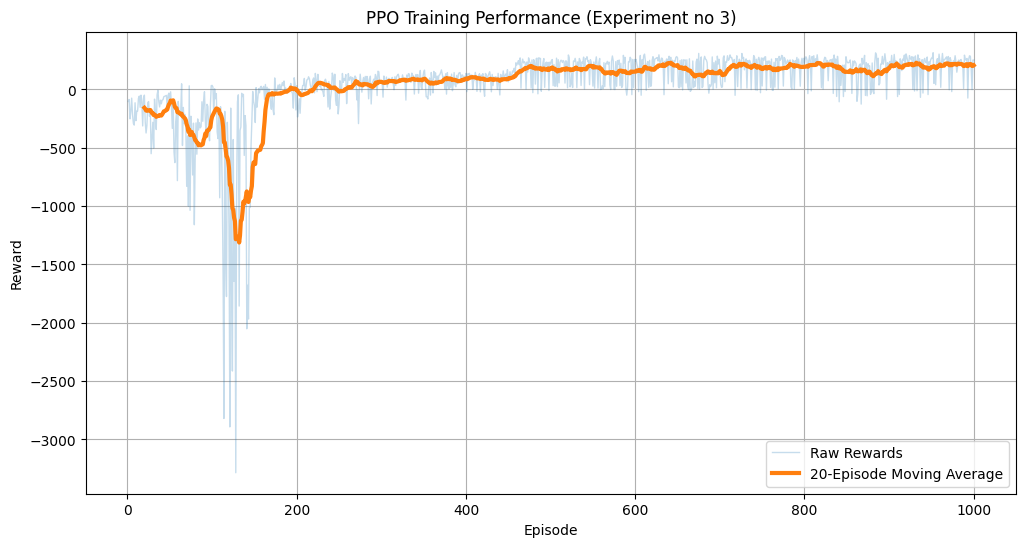

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# load saved CSV
df = pd.read_csv("ppo_rewards.csv")
# extract values
episodes = df["episode"]
rewards = df["reward"]
# moving average
window_size = 20
moving_avg = rewards.rolling(window=window_size).mean()
# plot
plt.figure(figsize=(12, 6))
# raw rewards in background
plt.plot(
    episodes,
    rewards,
    alpha=0.25,
    linewidth=1,
    label="Raw Rewards"
)
# moving average on top
plt.plot(
    episodes,
    moving_avg,
    linewidth=3,
    label=f"{window_size}-Episode Moving Average"
)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("PPO Training Performance (Experiment no 3)" )
plt.grid(True)
plt.legend()

plt.show()

Comparing all the experiments

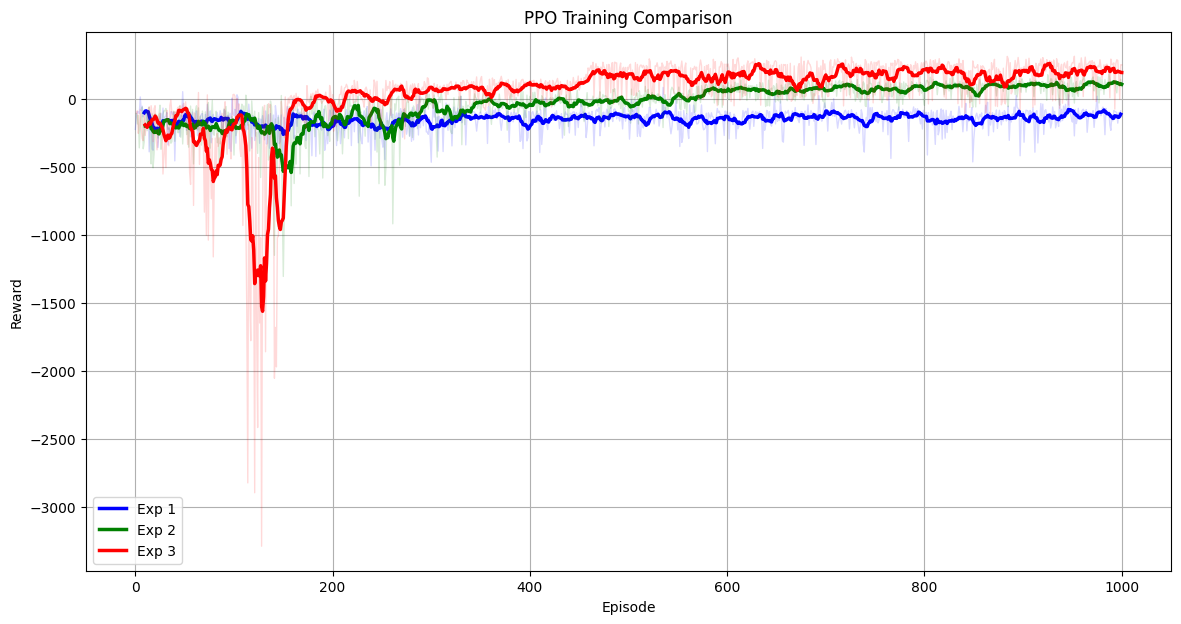

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Loading all the experiments
df1 = pd.read_csv("ppo_experiment_1.csv")
df2 = pd.read_csv("ppo_rewards_exp2.csv")
df3 = pd.read_csv("ppo_rewards.csv")

experiments = [
    ("Exp 1", df1, "blue"),
    ("Exp 2", df2, "green"),
    ("Exp 3", df3, "red"),
]

window_size = 10

plt.figure(figsize=(14, 7))

# plotting each experiment
for name, df, color in experiments:

    episodes = df["episode"]
    rewards = df["reward"]

    # moving average (smooth curve)
    smooth = rewards.rolling(window=window_size).mean()

    # raw rewards (background)
    plt.plot(
        episodes,
        rewards,
        color=color,
        alpha=0.15,
        linewidth=1
    )

    # smooth curve
    plt.plot(
        episodes,
        smooth,
        color=color,
        linewidth=2.5,
        label=name
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("PPO Training Comparison")

plt.grid(True)
plt.legend()

plt.show()

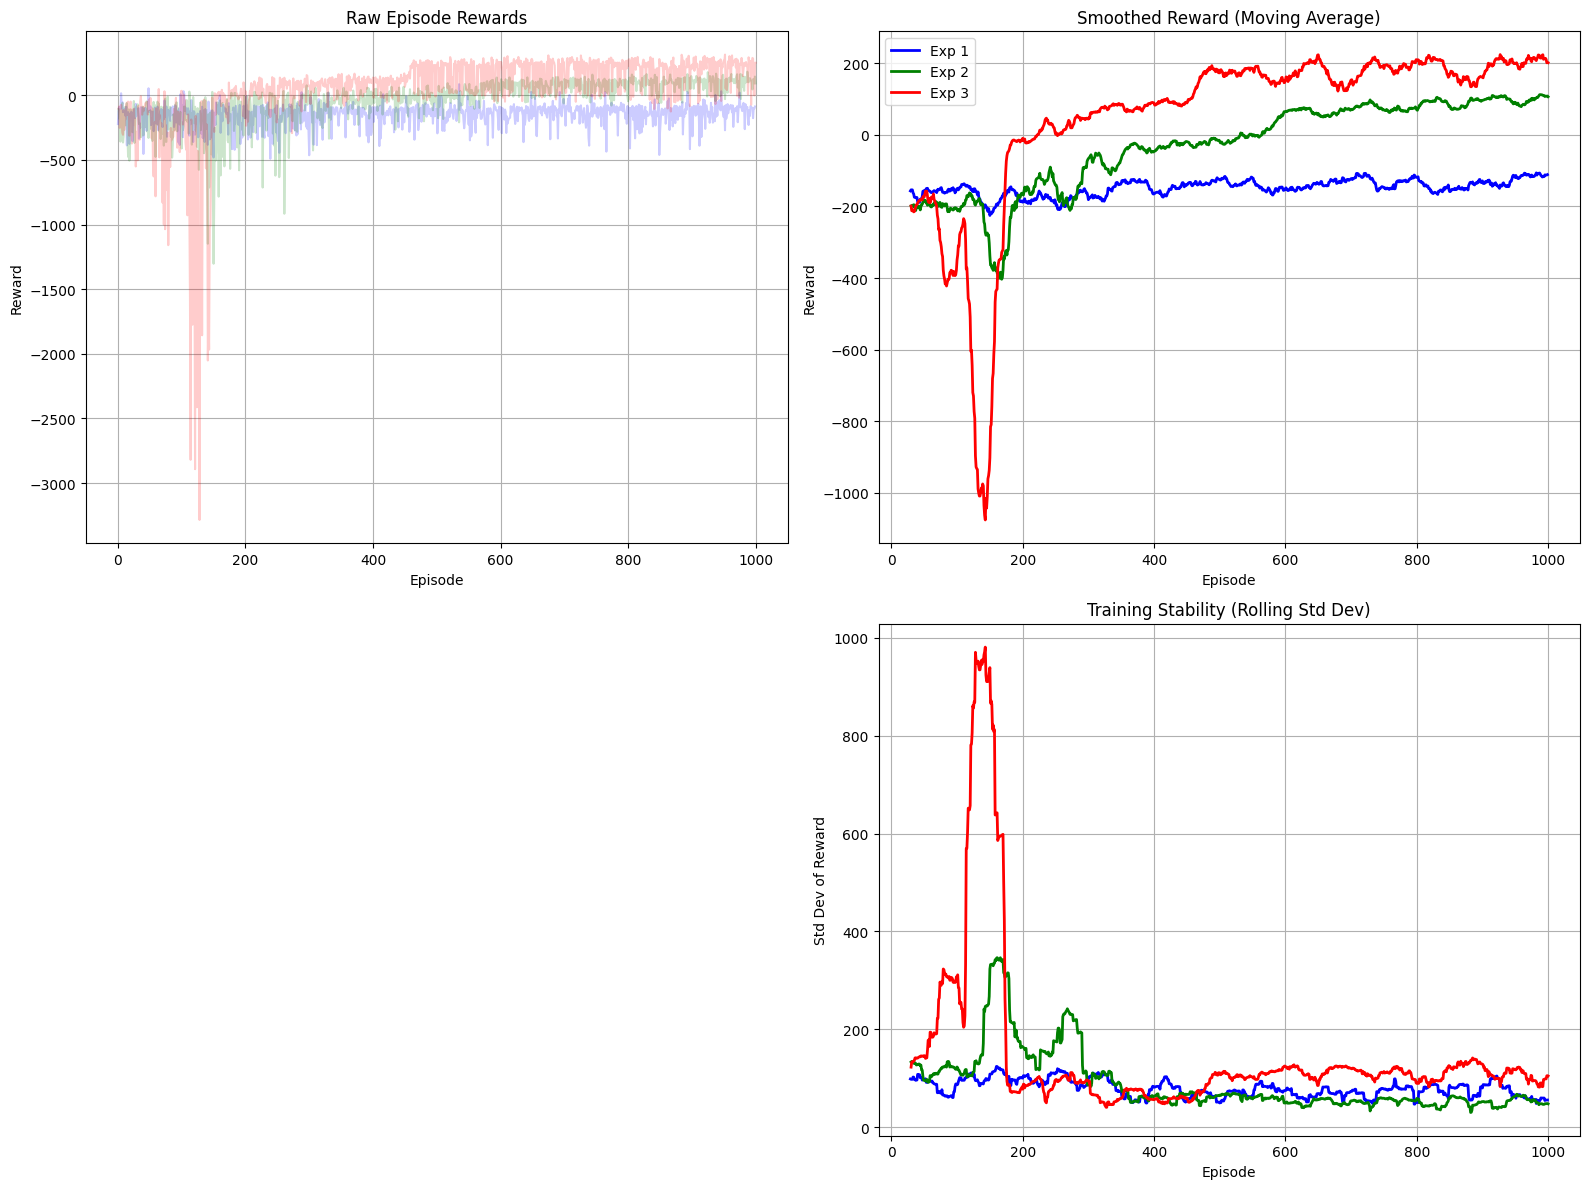

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load experiments
# -----------------------------
df1 = pd.read_csv("ppo_experiment_1.csv")
df2 = pd.read_csv("ppo_rewards_exp2.csv")
df3 = pd.read_csv("ppo_rewards.csv")

experiments = [
    ("Exp 1", df1, "blue"),
    ("Exp 2", df2, "green"),
    ("Exp 3", df3, "red"),
]

window = 30

# -----------------------------
# Create figure
# -----------------------------
plt.figure(figsize=(16, 12))

# =========================================================
# 1. RAW REWARDS (NOISY SIGNAL)
# =========================================================
plt.subplot(2, 2, 1)

for name, df, color in experiments:
    plt.plot(df["episode"], df["reward"], alpha=0.2, color=color)

plt.title("Raw Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)

# =========================================================
# 2. SMOOTHED REWARD (LEARNING TREND)
# =========================================================
plt.subplot(2, 2, 2)

for name, df, color in experiments:
    smooth = df["reward"].rolling(window).mean()
    plt.plot(df["episode"], smooth, label=name, linewidth=2, color=color)

plt.title("Smoothed Reward (Moving Average)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)

# =========================================================
# 4. LEARNING STABILITY (ROLLING STD)
# =========================================================
plt.subplot(2, 2, 4)

for name, df, color in experiments:
    rolling_std = df["reward"].rolling(window).std()
    plt.plot(df["episode"], rolling_std, linewidth=2, color=color)

plt.title("Training Stability (Rolling Std Dev)")
plt.xlabel("Episode")
plt.ylabel("Std Dev of Reward")
plt.grid(True)

plt.tight_layout()
plt.show()